# LangGraph Level 3A — Subgraph and Supervisor

Patterns covered:
1. **Subgraph as a node** — wrap a full graph and use it as a node inside a parent graph
2. **Supervisor pattern** — coordinator agent that decides which specialist to call at each step

> These two patterns are the foundation of hierarchical multi-agent architectures.

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Literal, Annotated, TypedDict
import operator
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

---
## 1. Subgraph as a node

**What is it?** A compiled graph can be used directly as a node inside another graph.
It lets you encapsulate complex logic and reuse it.

**Key rule:** The subgraph must share at least one state key with the parent graph so data can flow through.

```
Parent graph:
  [preprocess] → [subgraph_node] → [postprocess]
                     ↓
               Inner subgraph:
               [step_a] → [step_b] → [step_c]
```

Compiled subgraph:


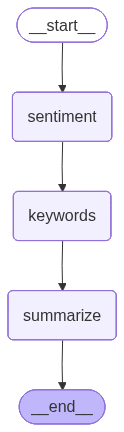

In [3]:
# ── SUBGRAPH: text analysis pipeline ─────────────────────────────────────────
# Subgraph state (must have keys compatible with the parent)
class AnalysisSubState(TypedDict):
    text: str        # shared with the parent
    sentiment: str
    keywords: list[str]
    summary: str

def detect_sentiment(state: AnalysisSubState) -> AnalysisSubState:
    response = llm.invoke([
        SystemMessage(content="Detect the sentiment. Reply ONLY with: positive / negative / neutral"),
        HumanMessage(content=state["text"])
    ])
    return {"sentiment": response.content.strip()}

def extract_keywords(state: AnalysisSubState) -> AnalysisSubState:
    response = llm.invoke([
        SystemMessage(content="Extract 3 key keywords. Reply ONLY as a comma-separated list."),
        HumanMessage(content=state["text"])
    ])
    keywords = [k.strip() for k in response.content.split(",")[:3]]
    return {"keywords": keywords}

def summarize(state: AnalysisSubState) -> AnalysisSubState:
    response = llm.invoke([
        SystemMessage(content="Summarize in at most 1 sentence."),
        HumanMessage(content=state["text"])
    ])
    return {"summary": response.content}

# Compile the subgraph
sub_builder = StateGraph(AnalysisSubState)
sub_builder.add_node("sentiment", detect_sentiment)
sub_builder.add_node("keywords", extract_keywords)
sub_builder.add_node("summarize", summarize)
sub_builder.add_edge(START, "sentiment")
sub_builder.add_edge("sentiment", "keywords")
sub_builder.add_edge("keywords", "summarize")
sub_builder.add_edge("summarize", END)

analysis_subgraph = sub_builder.compile()  # <-- compiled subgraph

print("Compiled subgraph:")
display(Image(analysis_subgraph.get_graph().draw_mermaid_png()))

Parent graph (with the subgraph expanded):


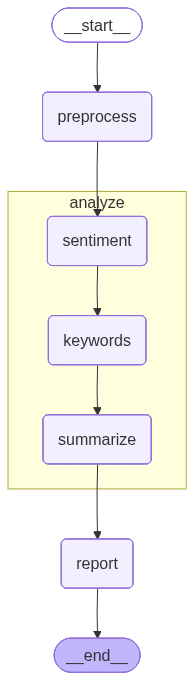

In [4]:
# ── PARENT GRAPH: uses the subgraph as a node ────────────────────────────────
class PipelineState(TypedDict):
    raw_input: str
    text: str          # shared key — the subgraph reads and writes here
    sentiment: str     # filled by the subgraph
    keywords: list[str]
    summary: str
    report: str

def preprocess(state: PipelineState) -> PipelineState:
    """Clean the text before passing it to the subgraph."""
    cleaned = state["raw_input"].strip().replace("\n", " ")
    return {"text": cleaned}

def generate_report(state: PipelineState) -> PipelineState:
    """Use the subgraph results to build a final report."""
    report = (
        f"ANALYSIS REPORT\n"
        f"Sentiment: {state['sentiment']}\n"
        f"Keywords: {', '.join(state.get('keywords', []))}\n"
        f"Summary: {state['summary']}"
    )
    return {"report": report}

parent_builder = StateGraph(PipelineState)
parent_builder.add_node("preprocess", preprocess)
parent_builder.add_node("analyze", analysis_subgraph)  # <-- subgraph as a node
parent_builder.add_node("report", generate_report)

parent_builder.add_edge(START, "preprocess")
parent_builder.add_edge("preprocess", "analyze")
parent_builder.add_edge("analyze", "report")
parent_builder.add_edge("report", END)

pipeline = parent_builder.compile()

print("Parent graph (with the subgraph expanded):")
display(Image(pipeline.get_graph(xray=True).draw_mermaid_png()))  # xray=True shows the inside of the subgraph

In [5]:
reviews = [
    "LangGraph is amazing, it has let me build complex pipelines in just a few hours.",
    "The documentation is confusing and the errors are unclear. I lost a whole day debugging.",
]

for review in reviews:
    result = pipeline.invoke({"raw_input": review})
    print(result["report"])
    print()

ANALYSIS REPORT
Sentiment: positive
Keywords: LangGraph, pipelines, build
Summary: LangGraph makes it easy to build complex pipelines in just a few hours.

ANALYSIS REPORT
Sentiment: negative
Keywords: documentation, confusing, errors
Summary: The confusing documentation and unclear errors made me lose an entire day debugging.



---
## 2. Supervisor Pattern — LLM coordinator + specialist agents

**What is it?** A Supervisor node that uses an LLM to decide which agent to call next.
Agents return their result and the Supervisor re-evaluates until it decides to finish.

**Key difference vs Routing (N2A):**
- Routing: classifier decides ONCE → corresponding branch → END
- Supervisor: can call multiple agents in sequence, deciding on every loop

```
Input → [Supervisor] → decides: researcher
            ↑              ↓
            └── [Researcher] → result → [Supervisor] → decides: writer
            ↑              ↓
            └── [Writer] → result → [Supervisor] → decides: FINISH
```

In [6]:
from typing import Literal

AGENTS = ["researcher", "writer"]
FINISH = "FINISH"

class RouteDecision(BaseModel):
    next: Literal["researcher", "writer", "FINISH"]
    reasoning: str

supervisor_llm = llm.with_structured_output(RouteDecision)

class WorkflowState(MessagesState):
    research_notes: str
    draft: str
    final_output: str

def supervisor(state: WorkflowState) -> Command[Literal["researcher", "writer", "__end__"]]:
    """Coordinator: decides which agent to call next based on conversation state."""
    system_prompt = (
        "You are a supervisor coordinating a writing team. "
        "You have two agents: 'researcher' (researches topics) and 'writer' (writes content). "
        f"Current state:\n"
        f"- research_notes: {'YES' if state.get('research_notes') else 'EMPTY'}\n"
        f"- draft: {'YES' if state.get('draft') else 'EMPTY'}\n"
        f"Decide: if research is missing → 'researcher'. "
        f"If research is done but draft is missing → 'writer'. "
        f"If a draft already exists → 'FINISH'."
    )
    decision = supervisor_llm.invoke([
        SystemMessage(content=system_prompt),
        *state["messages"]
    ])
    
    print(f"[Supervisor] → {decision.next} | {decision.reasoning}")
    
    goto = END if decision.next == FINISH else decision.next
    return Command(goto=goto)

def researcher(state: WorkflowState) -> Command[Literal["supervisor"]]:
    """Specialist: researches the topic and documents findings."""
    user_request = state["messages"][0].content
    response = llm.invoke([
        SystemMessage(content="You are an expert researcher. Produce 3-4 solid, concrete research bullet points."),
        HumanMessage(content=f"Research: {user_request}")
    ])
    print(f"[Researcher] Research completed")
    return Command(
        update={
            "research_notes": response.content,
            "messages": [AIMessage(content=f"[Researcher] {response.content}")]
        },
        goto="supervisor"
    )

def writer(state: WorkflowState) -> Command[Literal["supervisor"]]:
    """Specialist: writes content based on the research."""
    response = llm.invoke([
        SystemMessage(content="You are a technical writer. Turn the research bullet points into a clear 3-paragraph article."),
        HumanMessage(content=f"Research:\n{state['research_notes']}")
    ])
    print(f"[Writer] Draft completed")
    return Command(
        update={
            "draft": response.content,
            "final_output": response.content,
            "messages": [AIMessage(content=f"[Writer] {response.content[:100]}...")]
        },
        goto="supervisor"
    )

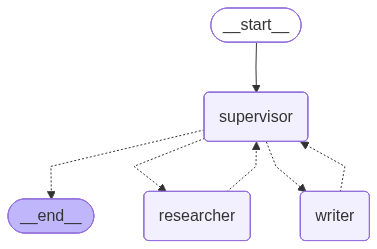

In [7]:
builder = StateGraph(WorkflowState)
builder.add_node("supervisor", supervisor)
builder.add_node("researcher", researcher)
builder.add_node("writer", writer)

# The flow always starts at the supervisor
builder.add_edge(START, "supervisor")
# Agents always go back to the supervisor via Command(goto="supervisor")
# The supervisor decides whether to go to an agent or to END via Command

supervisor_graph = builder.compile()
display(Image(supervisor_graph.get_graph().draw_mermaid_png()))

In [8]:
result = supervisor_graph.invoke({
    "messages": [HumanMessage(content="I need an article about the impact of LLMs on software development")]
})

print("\n=== FINAL RESULT ===")
print(result["final_output"])
print(f"\nConversation turns: {len(result['messages'])}")

[Supervisor] → researcher | Research on the impact of LLMs on software development is missing, so the 'researcher' should gather information before the 'writer' can draft the article.
[Researcher] Research completed
[Supervisor] → writer | Research on the impact of LLMs on software development is available, but the article has not been drafted yet.
[Writer] Draft completed
[Supervisor] → FINISH | Both research and a draft are now available, so the next step is to finalize the article.

=== FINAL RESULT ===
Large Language Models (LLMs) are reshaping software development by automating tasks that traditionally consume significant time, such as code generation, debugging, and documentation. Multiple case studies show that adopting LLMs can sharply reduce development time and improve overall team efficiency. By letting developers focus on more complex and creative tasks, these models not only streamline the workflow but also help raise the quality of the final product.

Beyond automation, L

---
## Subgraph vs Supervisor — when to use which

| | Subgraph | Supervisor |
|---|---|---|
| **Structure** | Graph inside a graph | Coordinator + agents in a loop |
| **Flow** | Linear and predictable | Dynamic, the LLM decides on each step |
| **Use** | Encapsulate reusable logic | Coordinate specialist agents |
| **State** | Shares keys with the parent | MessagesState with shared history |
| **When** | Deterministic pipeline | Problem that needs multiple variable steps |

**Next:** `N3B_swarm_send_api.ipynb` — Swarm (decentralized handoffs) + Send API (map-reduce)